In [2]:
import numpy as np
import gymnasium as gym
import pickle

# Create the environment
env = gym.make("CliffWalking-v1")

# Hyperparameters
n_states = env.observation_space.n    # 48 for CliffWalking
n_actions = env.action_space.n        # 4 (Up, Right, Down, Left)

q_table = np.zeros((n_states, n_actions))

alpha = 0.1       # Learning rate
gamma = 0.99      # Discount factor
epsilon = 1.0     # Initial exploration rate
epsilon_decay = 0.995
min_epsilon = 0.01
episodes = 1000

rewards_per_episode = []

for ep in range(episodes):
    state, _ = env.reset()
    total_reward = 0
    done = False

    while not done:
        # Choose action (ε-greedy)
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        # Step
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Q-value update
        best_next_action = np.max(q_table[next_state])
        q_table[state, action] = q_table[state, action] + alpha * (
            reward + gamma * best_next_action - q_table[state, action]
        )

        state = next_state
        total_reward += reward

    # Decay epsilon
    epsilon = max(min_epsilon, epsilon * epsilon_decay)
    rewards_per_episode.append(total_reward)

    if (ep + 1) % 100 == 0:
        print(f"Episode {ep+1}: Total Reward = {total_reward}, Epsilon = {epsilon:.3f}")

env.close()


Episode 100: Total Reward = -1710, Epsilon = 0.606
Episode 200: Total Reward = -138, Epsilon = 0.367
Episode 300: Total Reward = -15, Epsilon = 0.222
Episode 400: Total Reward = -13, Epsilon = 0.135
Episode 500: Total Reward = -16, Epsilon = 0.082
Episode 600: Total Reward = -13, Epsilon = 0.049
Episode 700: Total Reward = -13, Epsilon = 0.030
Episode 800: Total Reward = -13, Epsilon = 0.018
Episode 900: Total Reward = -13, Epsilon = 0.011
Episode 1000: Total Reward = -13, Epsilon = 0.010


In [3]:
with open("q_table.pkl", "wb") as f:
    pickle.dump(q_table, f)


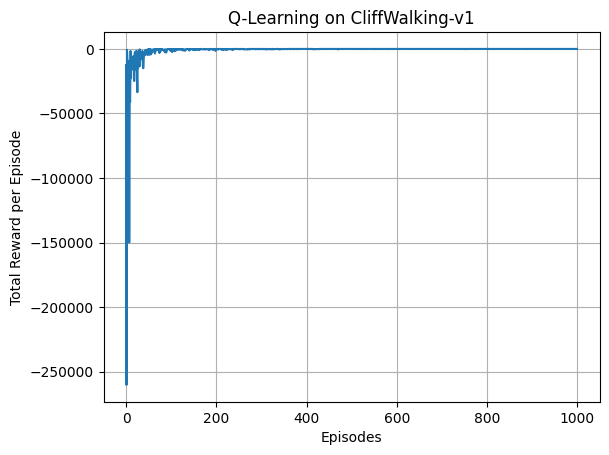

In [4]:
import matplotlib.pyplot as plt

plt.plot(rewards_per_episode)
plt.xlabel("Episodes")
plt.ylabel("Total Reward per Episode")
plt.title("Q-Learning on CliffWalking-v1")
plt.grid(True)
plt.show()


In [5]:
import gymnasium as gym
import pickle
import numpy as np
import time
import os

# Load the trained Q-table
with open("q_table.pkl", "rb") as f:
    q_table = pickle.load(f)


In [6]:
env = gym.make("CliffWalking-v1", render_mode="ansi")  # 'ansi' gives text-based rendering

state, _ = env.reset()
done = False
total_reward = 0

frames = []

while not done:
    # Choose the best action
    action = np.argmax(q_table[state])

    # Step through the environment
    next_state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated

    total_reward += reward
    state = next_state

    # Save the frame (text version of the env)
    frames.append(env.render())

env.close()

# Display the frames with a delay
os.system('cls' if os.name == 'nt' else 'clear')
for frame in frames:
    print(frame)
    time.sleep(0.4)  # Adjust speed here


o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
x  o  o  o  o  o  o  o  o  o  o  o
o  C  C  C  C  C  C  C  C  C  C  T


o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  x  o  o  o  o  o  o  o  o  o  o
o  C  C  C  C  C  C  C  C  C  C  T


o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  x  o  o  o  o  o  o  o  o  o
o  C  C  C  C  C  C  C  C  C  C  T


o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  x  o  o  o  o  o  o  o  o
o  C  C  C  C  C  C  C  C  C  C  T


o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  x  o  o  o  o  o  o  o
o  C  C  C  C  C  C  C  C  C  C  T


o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  x  o  o  o  o  o  o
o  C  C  C  C  C  C  C  C  C  C  T


o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  x  o  o  o  o  o
o  C  C  C  C  C  C  C  C  C  C  T


o  o  